In [27]:
import pandas as pd

In [28]:
!pip install seaborn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
import seaborn as sns

In [30]:
import matplotlib.pyplot as plt

In [31]:
df = pd.read_csv('../data/Benin/benin-malanville.csv', encoding='latin1', skiprows=[1])

In [32]:
print("summary statistics")
display(df.describe())

summary statistics


,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525599.000000,525599.000000,525599.000000,525599.000000,525599.000000,525599.000000,525599.000000,525599.000000,525599.000000,525599.000000,525599.000000,525599.000000,525599.000000,525599.000000,525599.000000,525599.000000,525599.000000,0.0
mean,240.559912,167.187834,115.359182,236.589946,228.884011,28.179687,54.487895,2.121117,2.809199,0.473390,153.435232,8.582423,994.197192,0.000923,0.001905,35.246043,32.471747,NaN
std,331.131474,261.710648,158.691144,326.895007,316.536659,5.924302,28.073044,1.603465,2.029119,0.273394,102.332930,6.385859,2.474990,0.030363,0.037115,14.807266,12.348752,NaN
min,-12.900000,-7.800000,-12.600000,0.000000,0.000000,11.000000,2.100000,0.000000,0.000000,0.000000,0.000000,0.000000,985.000000,0.000000,0.000000,9.000000,8.100000,NaN
25%,-2.000000,-0.500000,-2.100000,0.000000,0.000000,24.200000,28.800000,1.000000,1.300000,0.400000,59.000000,3.700000,993.000000,0.000000,0.000000,24.200000,23.600000,NaN
50%,1.800000,-0.100000,1.600000,4.500000,4.300000,28.000000,55.100000,1.900000,2.600000,0.500000,181.000000,8.600000,994.000000,0.000000,0.000000,30.000000,28.900000,NaN
75%,483.400000,314.200000,216.300000,463.700000,447.900000,32.300000,80.100000,3.100000,4.100000,0.600000,235.100000,12.300000,996.000000,0.000000,0.000000,46.900000,41.500000,NaN
max,1413.000000,952.300000,759.200000,1342.300000,1342.300000,43.800000,100.000000,19.500000,26.600000,4.200000,360.000000,99.400000,1003.000000,1.000000,2.500000,81.000000,72.500000,NaN


In [33]:
print("\nMissing Values:")
display(df.isna().sum())


Missing Values:


Timestamp             0
GHI                   0
DNI                   0
DHI                   0
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
Comments         525599
dtype: int64

In [34]:
import numpy as np

In [35]:
from scipy import stats

In [36]:
df = df.drop(columns=['Comments'])

checking for the negative values in GHI, DNI, DHI

In [37]:
radiation_cols=['GHI','DNI','DHI']
negative_cols = (df[radiation_cols]<0).sum()
print("Negative values in radiation columns:\n", negative_cols)

Negative values in radiation columns:
 GHI    258846
DNI    275986
DHI    259181
dtype: int64


Identify outliers using z-scores

In [38]:
cols_to_check = ['GHI','DNI','DHI', 'ModA','ModB','WS','WSgust']

In [39]:
z_scores= np.abs(stats.zscore(df[cols_to_check]))

In [40]:
outliers_mask=(z_scores>3).any(axis=1)

In [41]:
print(f"\nRows flagged as outliers: {outliers_mask.sum()}")


Rows flagged as outliers: 7740


In [42]:
for col in ['GHI','DNI','DHI']:
    df.loc[df[col]<0,col]=0

In [43]:
df_clean = df[~outliers_mask].copy()

In [44]:
print(f"Original rows: {len(df)}")
print(f"Cleaned rows:{len(df_clean)}")
print(f"Remaining negatives: {(df_clean[['GHI','DNI','DHI']]<0).sum().sum()}")

Original rows: 525599
Cleaned rows:517859
Remaining negatives: 0


In [45]:
df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'])

plots

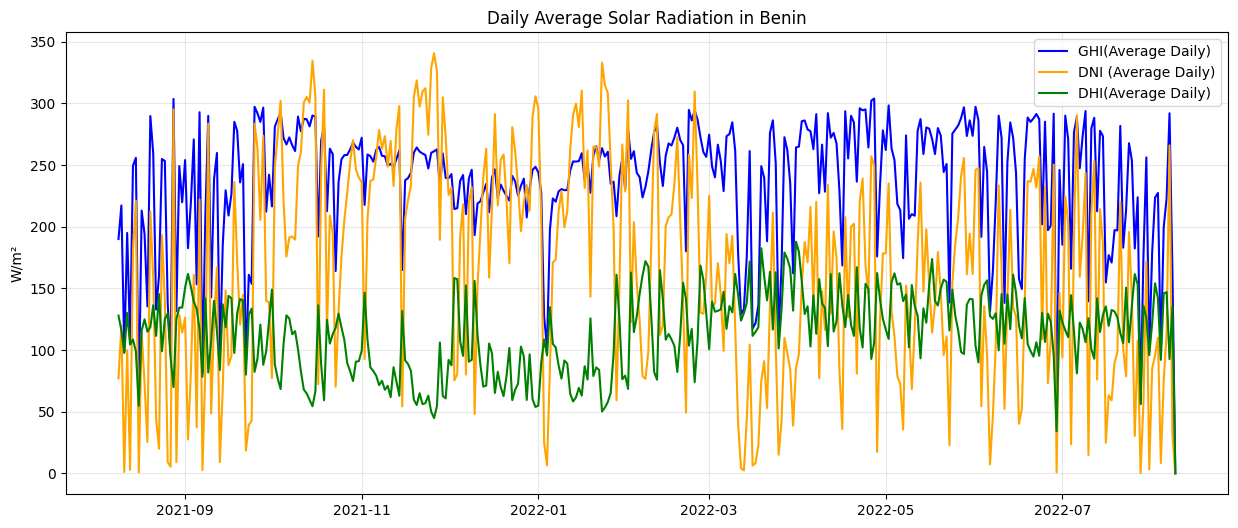

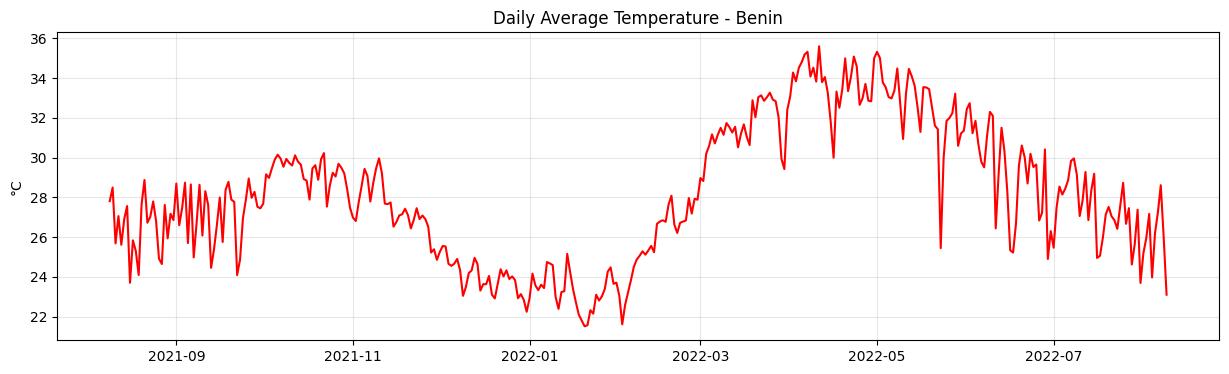

In [46]:
sample_data = df_clean.set_index('Timestamp').resample('D').mean()

plt.figure(figsize=(15,6))

plt.plot(sample_data.index, sample_data['GHI'], label='GHI(Average Daily)', color='blue')

plt.plot(sample_data.index, sample_data['DNI'], label='DNI (Average Daily)', color='orange')

plt.plot(sample_data.index, sample_data['DHI'], label='DHI(Average Daily)', color='green')

plt.title('Daily Average Solar Radiation in Benin')
plt.ylabel('W/m²')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Daily Average Temperature over time
plt.figure(figsize=(15, 4))
plt.plot(sample_data.index, sample_data['Tamb'], color='red')
plt.title('Daily Average Temperature - Benin')
plt.ylabel('°C')
plt.grid(True, alpha=0.3)
plt.show()


cleaning flag

In [47]:
cleaning_impact = df_clean.groupby('Cleaning')[['ModA','ModB']].mean()

Average sensor Readings (Cleaned vs uncleaned):


,ModA,ModB
Cleaning,,
0,232.324330,224.955525
1,306.610124,301.450000


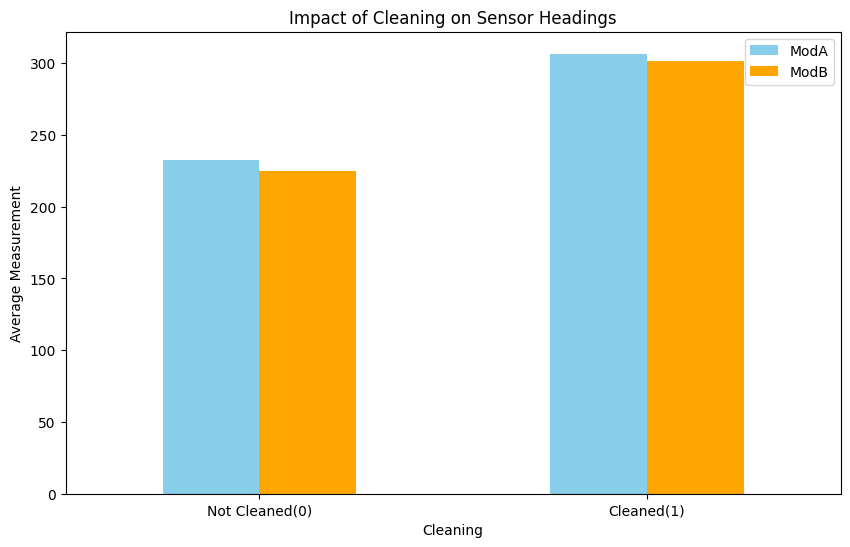

In [48]:
print("Average sensor Readings (Cleaned vs uncleaned):")
display(cleaning_impact)

#plot the impact
cleaning_impact.plot(kind='bar', figsize=(10,6),color=['skyblue','orange'])
plt.title('Impact of Cleaning on Sensor Headings')
plt.ylabel('Average Measurement')
plt.xticks([0,1],['Not Cleaned(0)', 'Cleaned(1)'], rotation=0)
plt.show()

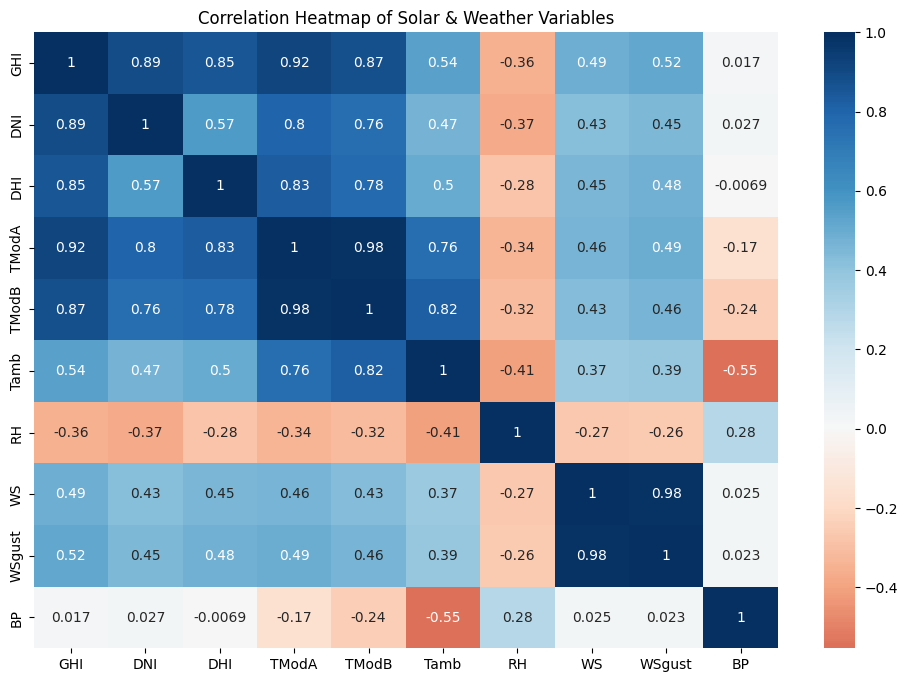

In [49]:
#selecting main columns for correlation
corr_cols = ['GHI', 'DNI', 'DHI', 'TModA', 'TModB', 'Tamb', 'RH', 'WS', 'WSgust', 'BP']
correlation_matrix = df_clean[corr_cols].corr()

# 2. Plot the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', center=0)
plt.title('Correlation Heatmap of Solar & Weather Variables')
plt.show()


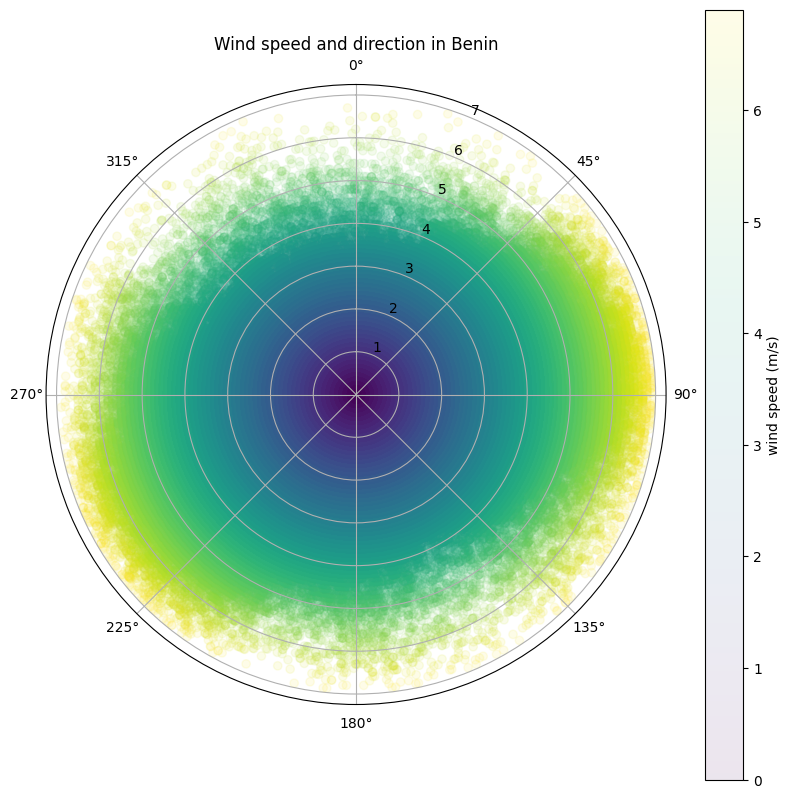

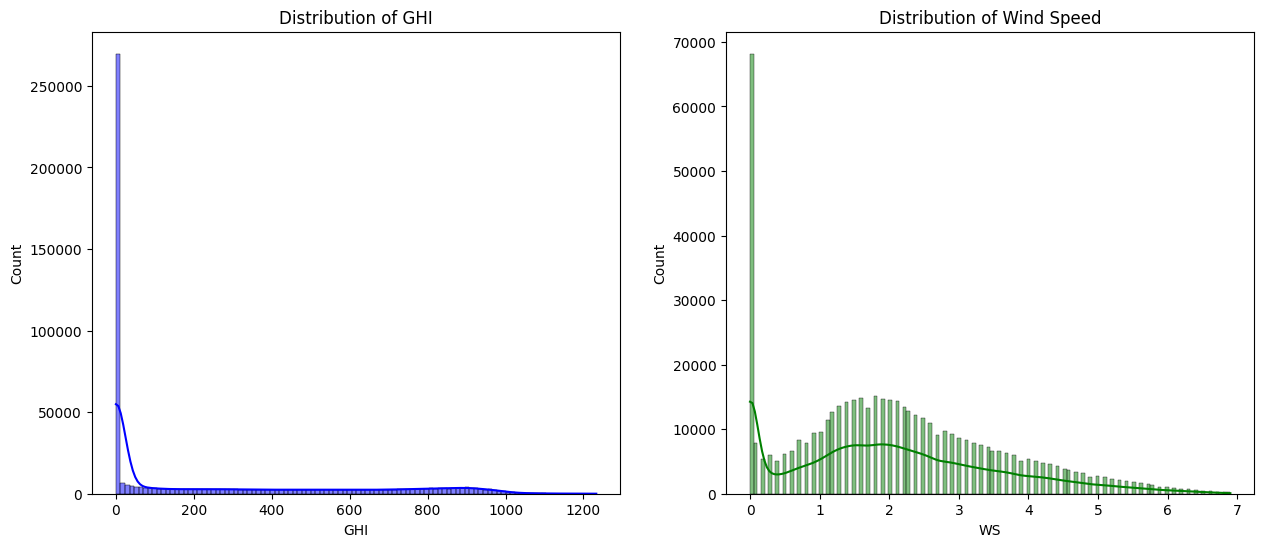

In [50]:
plt.figure(figsize=(10,10))
ax=plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_zero_location('N')

#plot wind direction and speed
plt.scatter(np.deg2rad(df_clean['WD']),
df_clean['WS'],alpha=0.1, c=df_clean['WS'],cmap='viridis')
plt.title('Wind speed and direction in Benin')
plt.colorbar(label='wind speed (m/s)')
plt.show()

#Distribution Analysis- histograms
# 2. Distribution Analysis - Histograms
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.histplot(df_clean['GHI'], kde=True, color='blue')
plt.title('Distribution of GHI')
plt.subplot(1, 2, 2)
sns.histplot(df_clean['WS'], kde=True, color='green')
plt.title('Distribution of Wind Speed')
plt.show()


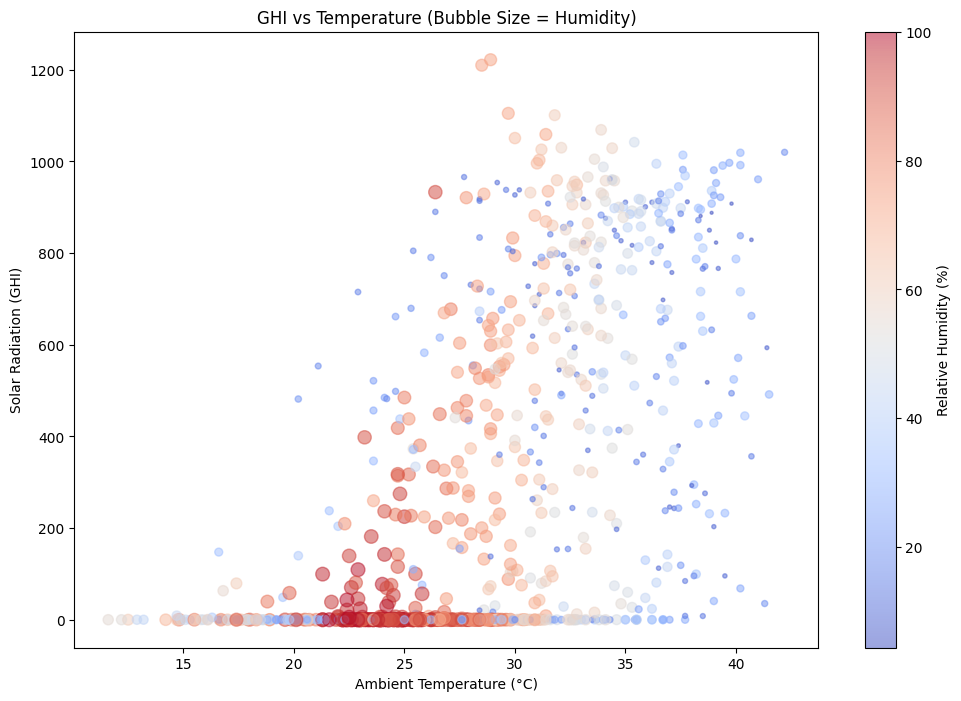

In [51]:
# Select a small random sample (e.g., 1000 rows) so the bubbles aren't too crowded
sample_bubble = df_clean.sample(1000)

plt.figure(figsize=(12, 8))
plt.scatter(sample_bubble['Tamb'], sample_bubble['GHI'], 
            s=sample_bubble['RH'], # Size of bubble = Humidity
            alpha=0.5, 
            c=sample_bubble['RH'], # Color can also = Humidity
            cmap='coolwarm')

plt.title('GHI vs Temperature (Bubble Size = Humidity)')
plt.xlabel('Ambient Temperature (°C)')
plt.ylabel('Solar Radiation (GHI)')
plt.colorbar(label='Relative Humidity (%)')
plt.show()


In [52]:
df_clean.to_csv('../data/benin_clean.csv', index=False)
print("Benin cleaned data saved!")


Benin cleaned data saved!
